In [1]:
# importing libraries needed for this project
import pandas as pd       
import numpy as np       
import matplotlib.pyplot as plt  
import seaborn as sns    

In [2]:


# reading the dataset and storing it as a dataframe
df = pd.read_csv(r'C:\Users\Ar\Desktop\stroke_prediction\data\stroke.csv')
print(df.shape)

(5110, 12)


In [3]:
#overview of data
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# checking column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
# checking basic statistics 
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
# checking if any column has missing values
print(df.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [7]:
# bmi has missing values - filling with median
# median is better than mean here because bmi can have outliers
median_bmi = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(median_bmi)
print('missing values after fix:', df.isnull().sum())

missing values after fix: id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [8]:
# dropping id column because it is just a unique identifier not a feature
df = df.drop(['id'], axis=1)
print('shape after dropping id:', df.shape)

shape after dropping id: (5110, 11)


In [10]:
# checking how many patients had a stroke vs did not
print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True) * 100)

stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


C:\Users\Ar\AppData\Local\Temp\ipykernel_20992\1214402102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette=['#1D9E75', '#D85A30'])
c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


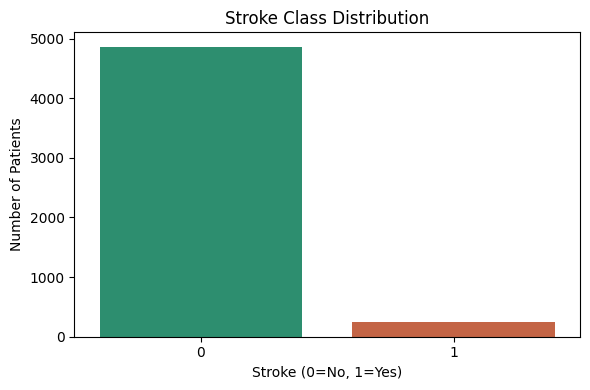

In [11]:
# bar chart to visualize class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette=['#1D9E75', '#D85A30'])
plt.title('Stroke Class Distribution')
plt.xlabel('Stroke (0=No, 1=Yes)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

In [12]:
# encoding categorical variables using one-hot encoding
# machine learning models only understand numbers not text
df_encoded = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type',
                                          'Residence_type', 'smoking_status'],
                             drop_first=True)
print('shape before encoding:', df.shape)
print('shape after encoding:', df_encoded.shape)
print('columns:', list(df_encoded.columns))

shape before encoding: (5110, 11)
shape after encoding: (5110, 17)
columns: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male', 'gender_Other', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [48]:
# encoding categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType',
                                          'RestingECG', 'ExerciseAngina',
                                          'ST_Slope'], drop_first=True)
print("shape before encoding:", df.shape)
print("shape after encoding:", df_encoded.shape)
print("columns:", list(df_encoded.columns))

shape before encoding: (918, 12)
shape after encoding: (918, 16)
columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [49]:
# splitting the data into features and target variable
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (918, 15)
y shape: (918,)


In [13]:
# splitting the data into features and target variable
# X contains input columns, y contains what we want to predict
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (5110, 16)
y shape: (5110,)


In [14]:
from sklearn.model_selection import train_test_split

# splitting the data into training and testing sets
# stratify=y makes sure both sets have same ratio of 0s and 1s
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('training samples:', X_train.shape[0])
print('testing samples:', X_test.shape[0])
print('training class balance:')
print(y_train.value_counts())

training samples: 4088
testing samples: 1022
training class balance:
stroke
0    3889
1     199
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler

# scaling converts all numbers to same range
# we fit scaler on training data only to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('scaling done')

scaling done


In [16]:
from imblearn.over_sampling import SMOTE

# stroke dataset is very imbalanced - only about 5% had a stroke
# SMOTE creates new synthetic patient records for minority class
# applied only on training data, test data must stay real
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('before SMOTE:', y_train.value_counts().to_dict())
print('after SMOTE:', y_train_smote.value_counts().to_dict())

before SMOTE: {0: 3889, 1: 199}
after SMOTE: {0: 3889, 1: 3889}


c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Ar\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 268, in _count_physical_cores
    cpu_count_physical = sum(map(int, cpu_info))
                         ^^^^^^^^^^^^^^^^^^^^^^^


In [17]:
from sklearn.linear_model import LogisticRegression

# training logistic regression on balanced training data
# logistic regression gives output between 0 and 1 - perfect for classification
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_smote, y_train_smote)
print('model trained')

model trained


In [18]:
# making predictions on the test set
# predict_proba gives probability scores between 0 and 1
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print('sample predictions:', y_pred[:10])
print('sample probabilities:', y_pred_proba[:10].round(2))

sample predictions: [0 0 0 0 1 0 0 0 0 0]
sample probabilities: [0.47 0.16 0.05 0.04 0.68 0.01 0.32 0.02 0.01 0.01]


In [19]:
import joblib

# saving model and scaler to disk for use in the streamlit app
# scaler must be saved too so new patient data is scaled the same way
joblib.dump(model, r'C:\Users\Ar\Desktop\stroke_prediction\model.pkl')
joblib.dump(scaler, r'C:\Users\Ar\Desktop\stroke_prediction\scaler.pkl')
print('model saved')
print('scaler saved')

model saved
scaler saved


In [20]:
from sklearn.metrics import confusion_matrix

# confusion matrix shows exactly where model went right and wrong
cm = confusion_matrix(y_test, y_pred)
print('confusion matrix:')
print(cm)

tn, fp, fn, tp = cm.ravel()
print('true negative:', tn)
print('false positive:', fp)
print('false negative:', fn)
print('true positive:', tp)

confusion matrix:
[[726 246]
 [ 10  40]]
true negative: 726
false positive: 246
false negative: 10
true positive: 40


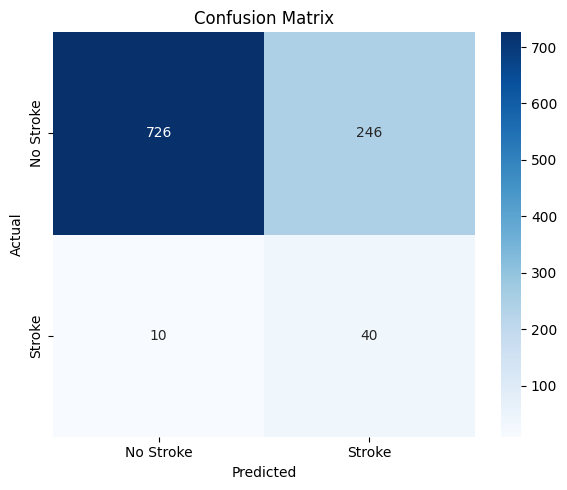

In [21]:
# heatmap makes confusion matrix easier to read visually
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [23]:
# calculating precision
precision = precision_score(y_test, y_pred)
print('precision:', round(precision * 100, 2), '%')


precision: 13.99 %


In [24]:
# calculating recall
recall = recall_score(y_test, y_pred)
print('recall:', round(recall * 100, 2), '%')


recall: 80.0 %


In [25]:
# calculating f1 score
f1 = f1_score(y_test, y_pred)
print('f1 score:', round(f1 * 100, 2), '%')

f1 score: 23.81 %


AUC score: 0.844


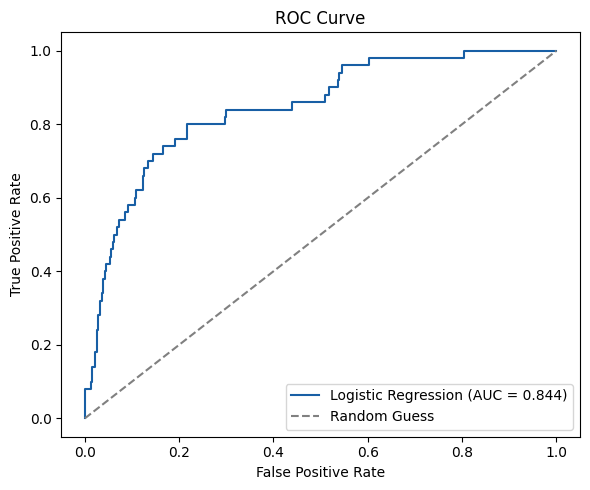

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

# calculating ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

print('AUC score:', round(auc_score, 3))

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#185FA5',
         label='Logistic Regression (AUC = ' + str(round(auc_score, 3)) + ')')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()



## Strengths and Limitations of Logistic Regression for Classification

### Strengths

* **Designed for classification:** Unlike Linear Regression, Logistic Regression is built specifically for binary classification problems like stroke prediction.
* **Output is a probability:** The sigmoid function ensures output is always between 0 and 1, which makes sense as a risk score.
* **Easy to understand:** Coefficients show how each feature affects the probability of stroke.
* **Fast to train:** Even on large datasets, Logistic Regression trains very quickly.

### Limitations

* **Assumes linear boundary:** Logistic Regression draws a straight line to separate classes. If the real boundary is curved it may not perform well.
* **Sensitive to outliers:** Extreme values in features like glucose or bmi can affect predictions.
* **Needs balanced data:** Class imbalance (95% no stroke vs 5% stroke) can bias the model which is why we used SMOTE.
* **May miss complex patterns:** More advanced models like Random Forest or XGBoost can capture non-linear relationships that Logistic Regression might miss.